# Young’s Double Slit Experiment (YDSE) – 3D Simulation

This notebook simulates the interference pattern in Young’s Double Slit Experiment using wave superposition.

## Physics Behind the Simulation

The intensity at any point is calculated using:

I ∝ |E₁ + E₂|²

where E₁ and E₂ are the electric field contributions from the two slits.

The simulation visualizes:
- 3D interference patterns
- Spatial variation of intensity
- Effect of phase difference on fringe formation

## Goal

To build an intuitive and visual understanding of how interference emerges from the superposition of waves.

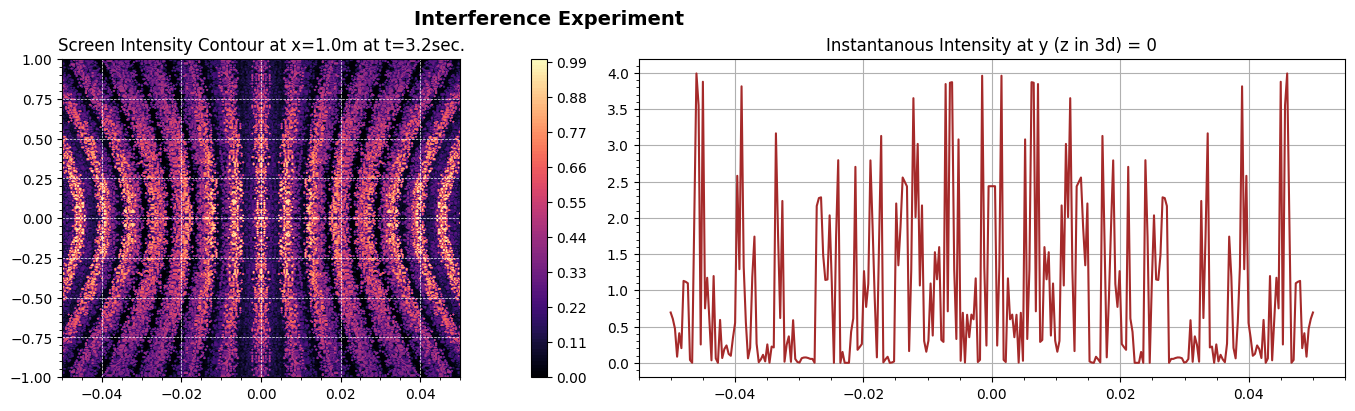

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import cm
from matplotlib import colors
from mpl_toolkits.mplot3d import axes3d



#Data input from user:




S=float(input("whats the screen pos? :"))
t=float(input("t at which to present the snapshot? :"))

#Initialize:

x=np.linspace(0,S,300)
y=np.linspace(-0.05,0.05, 300)
z=np.linspace(-1, 1, 300)


X,Y=np.meshgrid(x,y)

Γ,ζ=np.meshgrid(y,z)

#Constants :

λ=6.5*10**-7
c=3e8 # 3e8 m/s
A=1


k=2*np.pi/λ  
ω=c*k #

d=1e-4


s1=(0,d/2,0)
s2=(0,-d/2,0)

# Defining the light waves:

def o1(x,y,z,t):

    r1 = np.sqrt((x-s1[0])**2 + (y-s1[1])**2 +(z-s1[2])**2 )
    a=(A/r1)*np.sin(ω*t-k*r1)
    return a

def o2(x,y,z,t):

    r2 = np.sqrt((x-s2[0])**2 + (y-s2[1])**2 + (z-s2[2])**2)
    a= (A/r2)*np.sin(ω*t-k*r2)
    return a


#Intensity (instantanous) calculation:

def get_int_screen(S,t):
    I=(o1(S,Γ,ζ,t)+o2(S,Γ,ζ,t))**2
    
    I0=(o1(S,y,0,t)+o2(S,y,0,t))**2
    
    return I , I0


#Plotting:
def plot_tinst(S,t):
    

    fig, ax = plt.subplots(1,2,figsize=(16, 4), constrained_layout=True)

    fig.suptitle("Interference Experiment",
             fontsize=14,
             fontweight="bold")
    

    ax[0].set_title(f"Screen Intensity Contour at x={S}m at t={t}sec.")
    ax[0].set_box_aspect(0.8)

    ax[0].set_xlim(min(y), max(y))
    ax[0].set_ylim(min(z), max(z))

    cont2 = ax[0].contourf(
    Γ,
    ζ,
    get_int_screen(S, t)[0] / np.max(get_int_screen(S, t)[0]),
    levels=100,
    cmap="magma")

    ax[0].grid(True, color="white", linestyle="--", linewidth=0.5)
    ax[0].minorticks_on()

    fig.colorbar(
    cont2,
    ax=ax[0],
    orientation="vertical",
    pad=0.1,
    fraction=0.08)

    
    ax[1].set_title("Instantanous Intensity at y (z in 3d) = 0")
    ax[1].plot(y,get_int_screen(S,t)[1],color="brown")
    ax[1].grid(True)
    ax[1].minorticks_on()
 

plot_tinst(S,t)


# Time avg intensity

In [7]:
t1=np.linspace(0,1,1000)

def plot_tavg(t1,S1):
 
  I=np.zeros_like(get_int_screen(S1,0)[0])
  I0=np.zeros_like(get_int_screen(S1,0)[1])

  for n in t1:

    I+=get_int_screen(S1,n)[0]
    I0+=get_int_screen(S1,n)[1]
 
  I=I/np.max(I)
  I0=I0/np.max(I0)

  fig, ax = plt.subplots(1,2,figsize=(16,4))

  fig.suptitle("Interference Experiment",
             fontsize=14,
             fontweight="bold")

  ax[0].set_title(f"Screen Time avg Intensity Contour at x={S1}m")
  ax[0].set_box_aspect(0.8)

  ax[0].set_xlim(min(y), max(y))
  ax[0].set_ylim(min(z), max(z))

  cont1 = ax[0].contourf(
    Γ,
    ζ,
    I/len(t1),
    levels=300,
    cmap="magma"
)

  ax[0].grid(
    True,
    color="white",
    linestyle="--",
    linewidth=0.5
)

  ax[0].minorticks_on()

  fig.colorbar(
    cont1,
    ax=ax[0],
    orientation="vertical",
    pad=0.1,
    fraction=0.08

)

  ax[1].set_title("Intensity at y(z in 3d)=0")


  ax[1].set_title("Intensity at y(z in 3d)=0")
  ax[1].plot(y,I0/len(t1),color="red")
  ax[1].grid(True)
  ax[1].minorticks_on()
  plt.show()


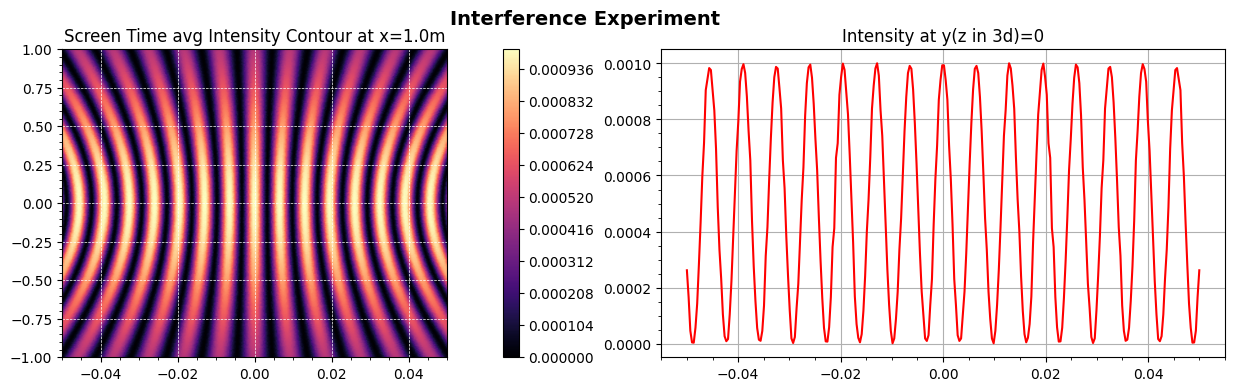

In [9]:
plot_tavg(t1,S)

## Data Collection

The following section contains data collected from the mathematical and computational analysis presented above. The results have been obtained through numerical evaluation and simulation of the governing equations under the assumptions and parameter ranges specified earlier.

This section is intended to provide a systematic record of the observed behavior of the system as selected parameters are varied. Unless otherwise noted, all quantities not explicitly designated as variables remain fixed throughout the analysis.

The data presented here form the basis for subsequent comparison, interpretation, and discussion of the interference patterns and their dependence on the chosen physical parameters.

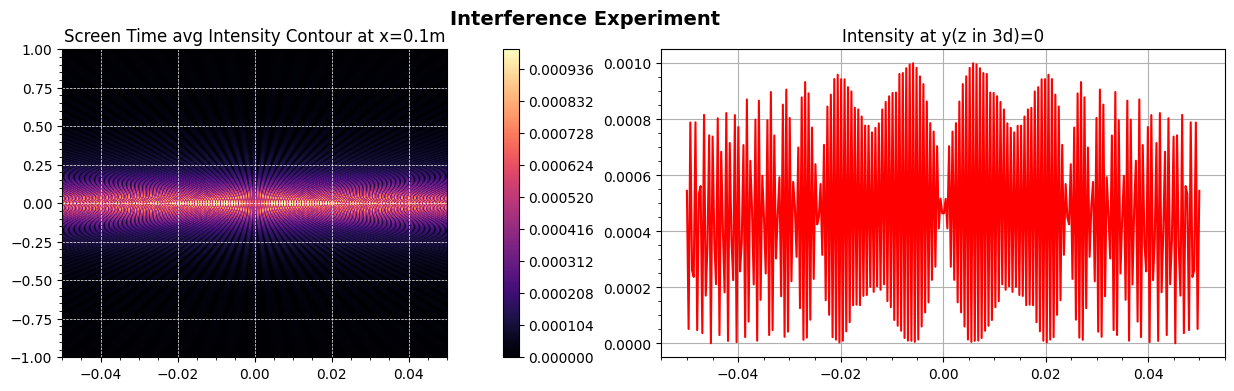

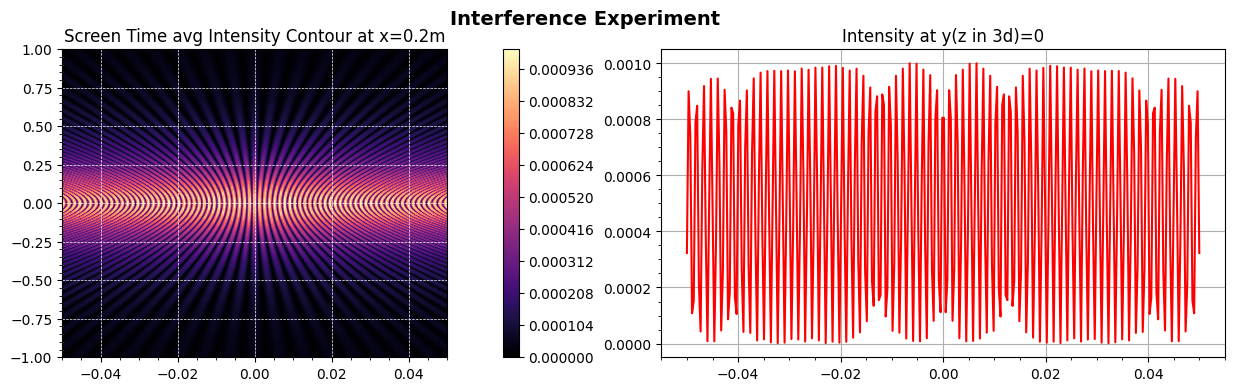

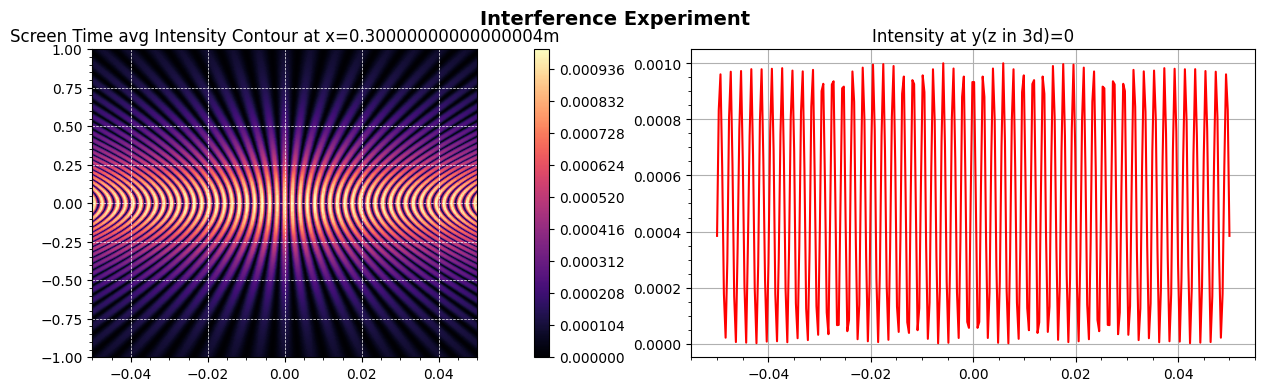

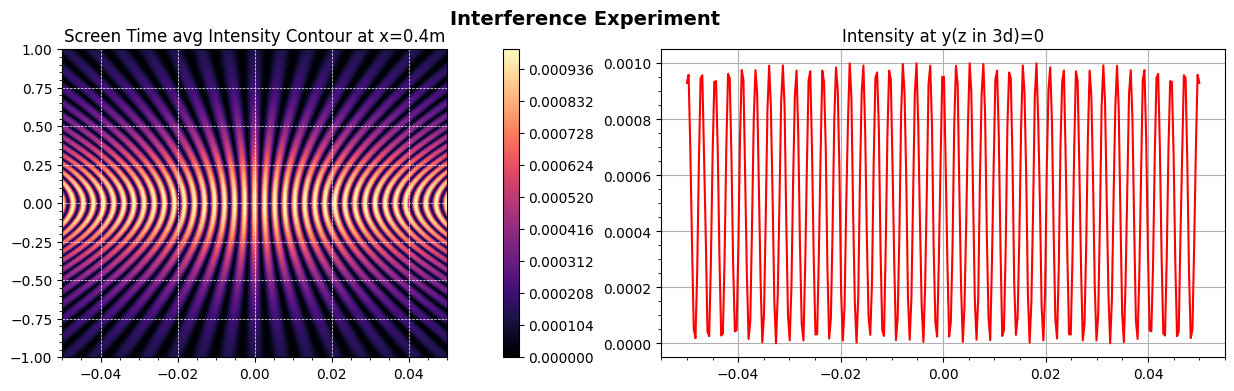

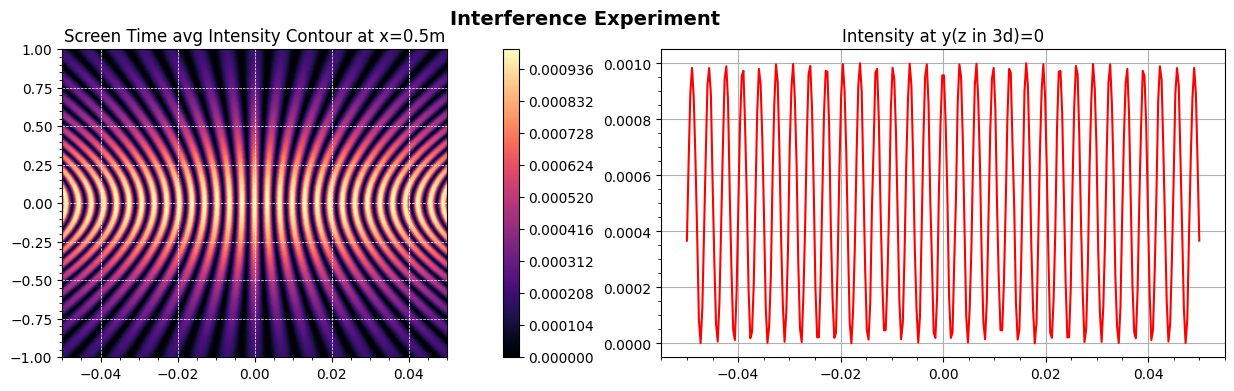

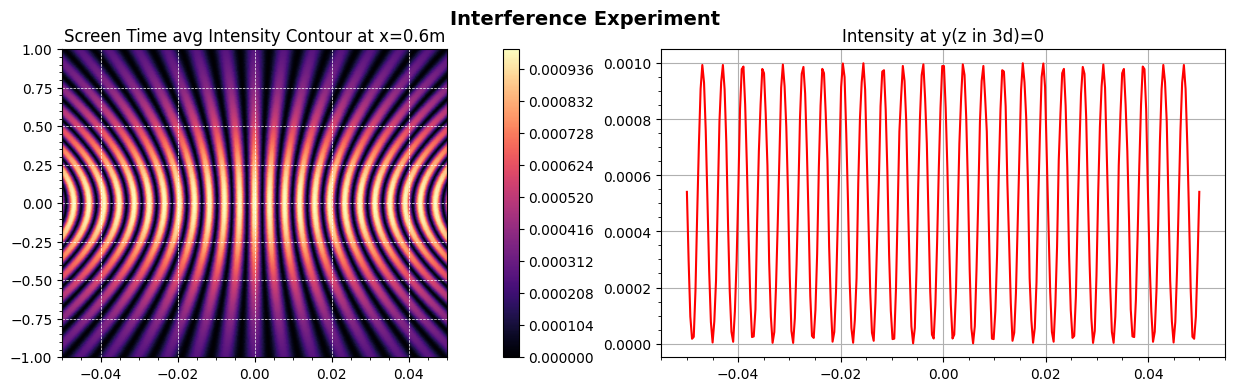

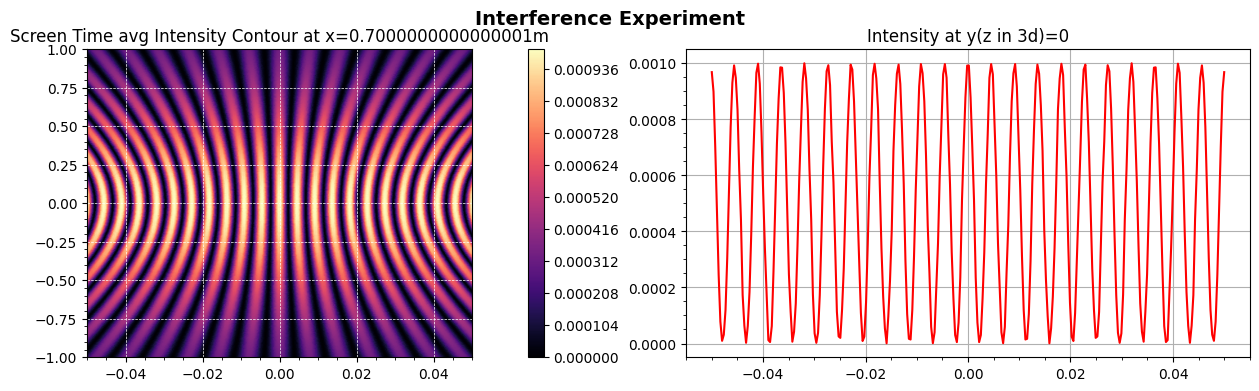

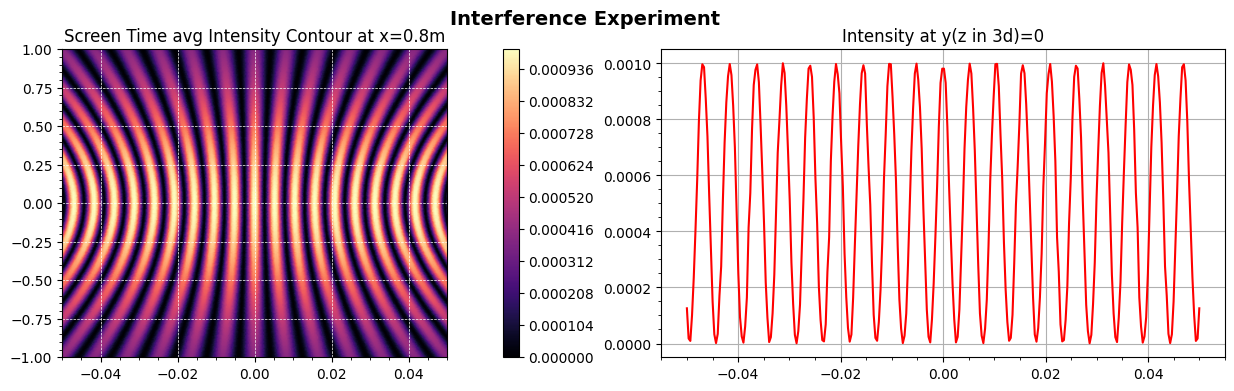

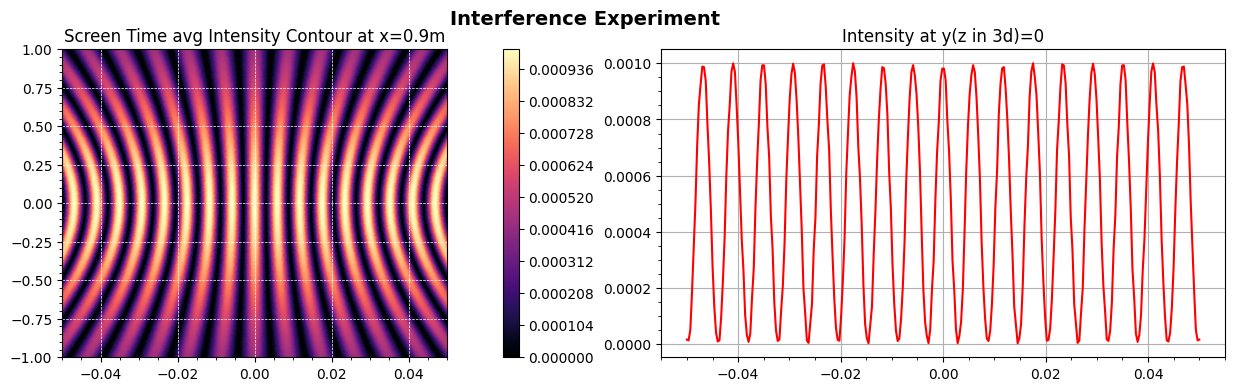

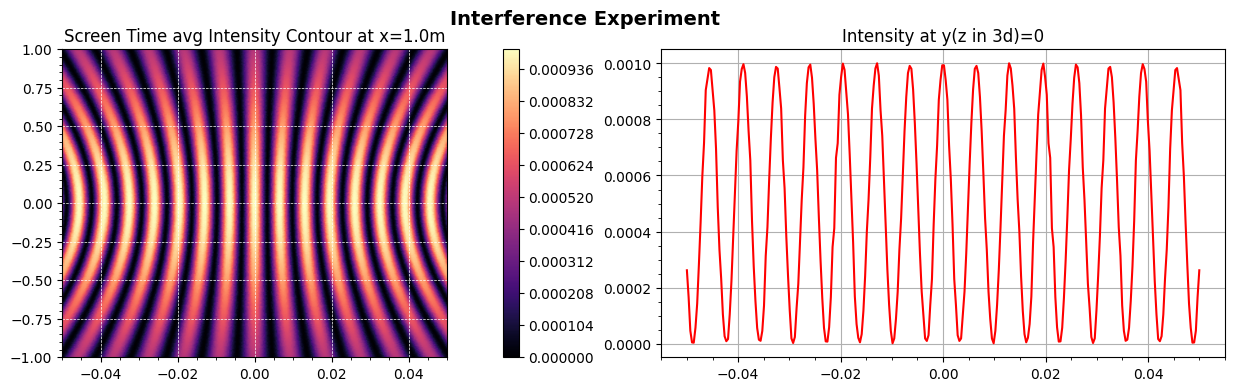

In [11]:
D=np.linspace(0.1,1,10)

for n in D:
    plot_tavg(t1,n)